# 4 — Full Training

**Goal:** Train the student model (`MobileStudentCNN`) on the full ASVspoof 2019 LA training set (25,380 samples) using Knowledge Distillation from the frozen Wav2Vec2 teacher.

Key improvements over medium training:
- Full dataset (25,380 samples vs 5,000)
- `ReduceLROnPlateau` scheduler — smoother convergence, no oscillation
- Resume capability — training continues from checkpoint if interrupted
- Early stopping based on EER (patience=6)

> ⚠️ **This notebook does not retrain the model.** `student_best.pth` is already trained and saved on Drive. This notebook loads the saved model, displays the training curves, and verifies the final results.

Run `1_setup_dataset.ipynb` first to extract the dataset.

In [2]:
import os
import sys
import torch
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from google.colab import drive

# Mount Drive
drive.mount('/content/drive')

# Clone repo + add src/ to path
PROJECT_DIR = '/content/project'
SRC_DIR     = os.path.join(PROJECT_DIR, 'src')

if not os.path.exists(PROJECT_DIR):
    !git clone https://github.com/Arjun11x/deepfake-audio-detection.git {PROJECT_DIR}
else:
    !cd {PROJECT_DIR} && git pull

if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

# Configure paths
import config
config.ENV          = "colab"
config.DATASET_ROOT = "/content/asvspoof2019/LA"
config.AUDIO_DIRS   = {
    "train" : "/content/asvspoof2019/LA/ASVspoof2019_LA_train/flac",
    "dev"   : "/content/asvspoof2019/LA/ASVspoof2019_LA_dev/flac",
    "eval"  : "/content/asvspoof2019/LA/ASVspoof2019_LA_eval/flac",
}
config.PROTOCOL_FILES = {
    "train" : "/content/asvspoof2019/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt",
    "dev"   : "/content/asvspoof2019/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.dev.trl.txt",
    "eval"  : "/content/asvspoof2019/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.eval.trl.txt",
}
config.SAVE_DIR        = "/content/drive/MyDrive/deepfake_detector/models"
config.BEST_MODEL_PATH = f"{config.SAVE_DIR}/student_best.pth"
config.CHECKPOINT_PATH = f"{config.SAVE_DIR}/training_checkpoint.pth"
os.makedirs(config.SAVE_DIR, exist_ok=True)

# Patch config.py in cloned repo to use colab ENV
# This ensures train.py uses correct paths when called as a subprocess
!sed -i 's/ENV = "local"/ENV = "colab"/' /content/project/src/config.py
print("✅ config.py patched to colab ENV")

# Extract dataset if needed
ZIP_PATH    = '/content/drive/MyDrive/LA.zip'
EXTRACT_DIR = '/content/asvspoof2019'
LA_DIR      = os.path.join(EXTRACT_DIR, 'LA')

if os.path.exists(LA_DIR):
    print(f'✅ Dataset already extracted')
else:
    print(f'Extracting dataset...')
    os.makedirs(EXTRACT_DIR, exist_ok=True)
    !unzip -q {ZIP_PATH} -d {EXTRACT_DIR}
    print(f'✅ Extraction complete')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n✅ Setup complete | Device: {device}")
print(f"  Save dir        : {config.SAVE_DIR}")
print(f"  Best model path : {config.BEST_MODEL_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Already up to date.
✅ config.py patched to colab ENV
✅ Dataset already extracted

✅ Setup complete | Device: cuda
  Save dir        : /content/drive/MyDrive/deepfake_detector/models
  Best model path : /content/drive/MyDrive/deepfake_detector/models/student_best.pth


## 4.1 — Run Training

Calls `train.py` directly from the cloned repo with `--skip_if_trained` flag.

- If `student_best.pth` already exists on Drive → skips training, prints model info
- If not → runs full training with `ReduceLROnPlateau` scheduler and early stopping

In [3]:
!python /content/project/src/train.py --skip_if_trained

  Active ENV       : colab
  Project root     : /content/project
  Dataset root     : /content/asvspoof2019/LA
  Save directory   : /content/drive/MyDrive/deepfake_detector/models
  LR               : 0.0005
  Temperature      : 6.0
  Alpha            : 0.7
  Batch size       : 16

Device: cuda

  SKIPPING TRAINING — model already exists
  Path       : /content/drive/MyDrive/deepfake_detector/models/student_best.pth
  Size       : 0.9 MB
  Parameters : 230,058

  To retrain from scratch:
  1. Delete /content/drive/MyDrive/deepfake_detector/models/student_best.pth
  2. Re-run without --skip_if_trained flag


## 4.2 — Training Curves

Training curves from the full training run — Loss, Accuracy, EER, and Learning Rate across all epochs.

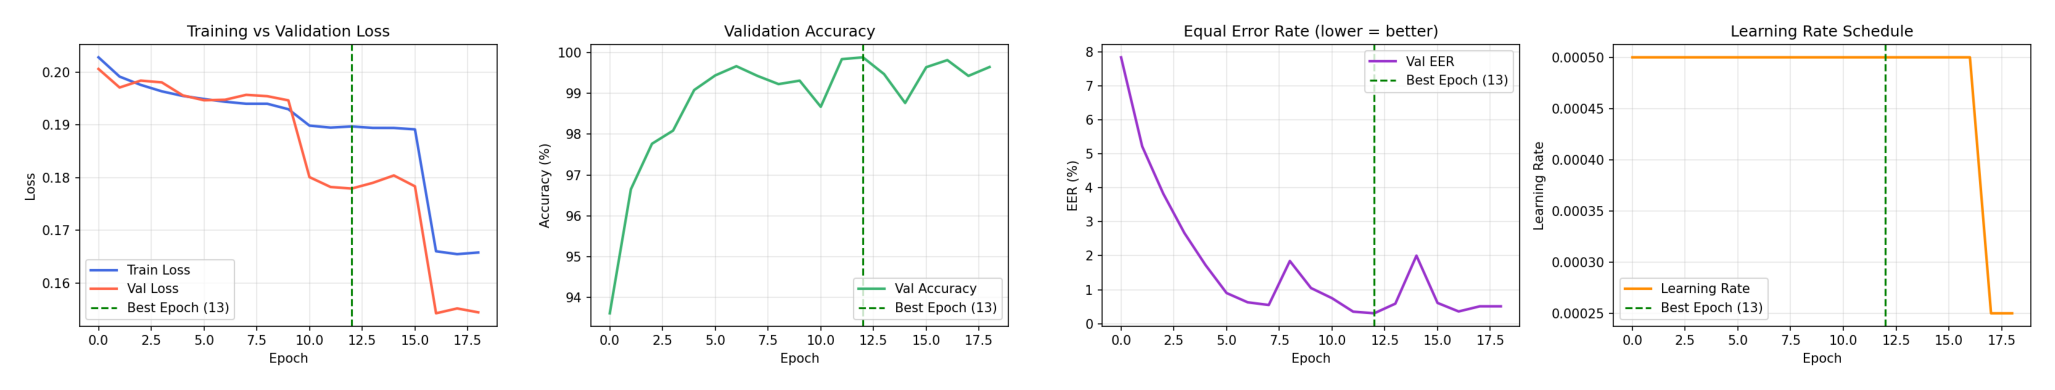

✅ Loaded → /content/drive/MyDrive/deepfake_detector/models/full_training_curves_v2.png


In [4]:
# Load and display saved training curves from Drive
curves_path = f"{config.SAVE_DIR}/full_training_curves_v2.png"

assert os.path.exists(curves_path), f"[ERROR] Curves not found at {curves_path}"

img = mpimg.imread(curves_path)
plt.figure(figsize=(22, 4))
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()
print(f"✅ Loaded → {curves_path}")

## 4.3 — Verify Trained Model

Load `student_best.pth` and verify it runs correctly — confirm output shape, parameter count, and model size.

In [5]:
from models import MobileStudentCNN

# Load best model
student = MobileStudentCNN().to(device)
student.load_state_dict(torch.load(config.BEST_MODEL_PATH, map_location=device))
student.eval()

# Model info
size_mb    = os.path.getsize(config.BEST_MODEL_PATH) / (1024 * 1024)
num_params = sum(p.numel() for p in student.parameters())

# Quick forward pass to verify
dummy = torch.randn(2, 1, 64, 126).to(device)
with torch.no_grad():
    out = student(dummy)

assert out.shape == torch.Size([2, 2]), f"Shape mismatch: {out.shape}"

print(f"{'='*50}")
print(f"  MODEL VERIFICATION")
print(f"{'='*50}")
print(f"  Path       : {config.BEST_MODEL_PATH}")
print(f"  Size       : {size_mb:.1f} MB")
print(f"  Parameters : {num_params:,} (~{num_params/1e6:.2f}M)")
print(f"  Output     : {out.shape}  (Expected: [2, 2])")
print(f"  Device     : {device}")
print(f"{'='*50}")
print(f"  ✅ Model loaded and verified successfully")

  MODEL VERIFICATION
  Path       : /content/drive/MyDrive/deepfake_detector/models/student_best.pth
  Size       : 0.9 MB
  Parameters : 230,058 (~0.23M)
  Output     : torch.Size([2, 2])  (Expected: [2, 2])
  Device     : cuda
  ✅ Model loaded and verified successfully


## 4.4 — Training Summary

Final confirmed results from full training on ASVspoof 2019 LA.

In [6]:
print(f"{'='*55}")
print(f"  FULL TRAINING SUMMARY")
print(f"{'='*55}")
print(f"""
  Dataset:
  ├── Train : 25,380 samples (balanced)
  ├── Dev   : 24,844 samples (natural distribution)
  └── Scheduler : ReduceLROnPlateau (factor=0.5, patience=3)

  Hyperparameters (confirmed from sweep + medium training):
  ├── Learning Rate : 0.0005
  ├── Temperature   : 6.0
  ├── Alpha         : 0.7  (70% soft KD + 30% hard CE)
  └── Batch Size    : 16

  Training Results:
  ├── Best Epoch    : 13
  ├── Stopped At    : Epoch 19  (early stopping patience=6)
  ├── Best Dev EER  : 0.30%  ← seen attacks A01-A06
  └── Final LR      : 0.000250  (reduced by ReduceLROnPlateau)

  Model:
  ├── Architecture  : MobileStudentCNN
  ├── Parameters    : 230,058  (~0.23M)
  ├── Size          : 0.9 MB
  └── Saved at      : {config.BEST_MODEL_PATH}

  vs Teacher (Wav2Vec2):
  ├── Teacher params : 94.4M  (frozen)
  └── Compression    : 410x smaller than teacher
""")
print(f"{'='*55}")
print(f"  Next → 5_evaluation_inference.ipynb")
print(f"{'='*55}")

  FULL TRAINING SUMMARY

  Dataset:
  ├── Train : 25,380 samples (balanced)
  ├── Dev   : 24,844 samples (natural distribution)
  └── Scheduler : ReduceLROnPlateau (factor=0.5, patience=3)

  Hyperparameters (confirmed from sweep + medium training):
  ├── Learning Rate : 0.0005
  ├── Temperature   : 6.0
  ├── Alpha         : 0.7  (70% soft KD + 30% hard CE)
  └── Batch Size    : 16

  Training Results:
  ├── Best Epoch    : 13
  ├── Stopped At    : Epoch 19  (early stopping patience=6)
  ├── Best Dev EER  : 0.30%  ← seen attacks A01-A06
  └── Final LR      : 0.000250  (reduced by ReduceLROnPlateau)

  Model:
  ├── Architecture  : MobileStudentCNN
  ├── Parameters    : 230,058  (~0.23M)
  ├── Size          : 0.9 MB
  └── Saved at      : /content/drive/MyDrive/deepfake_detector/models/student_best.pth

  vs Teacher (Wav2Vec2):
  ├── Teacher params : 94.4M  (frozen)
  └── Compression    : 410x smaller than teacher

  Next → 5_evaluation_inference.ipynb
